In [43]:
import numpy as np
import matplotlib.pyplot as plt
#Creation of Thomas Algorithm
def thomas_algorithm(a, b, c, d):
    n = len(b)
    a = np.array(a, dtype= float)
    b = np.array(b, dtype= float)
    c = np.array(c, dtype= float)
    d = np.array(d, dtype= float)

    for i in range(1,n):
        w = a[i] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i]- c[i]* x[i+1])/ b[i]
    return x
    
#Creation of Cubic Spline Algorithm     
    
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
# Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
# Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i -1] # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * ( (y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1] ) # Right-hand side vector

    M_second = thomas_algorithm(A, B, C, D)
    # Natural boundary conditions
    M = np.zeros(n)
    M[1:n - 1] = M_second
    return M

#Finding the correct interval for each point, I got this part from slides in 13.b 
def evaluate_spline(x_data, y_data, M, x_query):
    n = len(x_data)
    
    h = np.diff(x_data)
    i = np.searchsorted(x_data, x_query, side='right') - 1
    
    i = np.clip(i, 0, n - 2)
    
    
    hi = h[i]
    dx_left = x_query - x_data[i] 
    
    
    dx_right = x_data[i+1] - x_query
    S = (
        (M[i] / (6*hi)) * dx_right**3 + 
        (M[i+1] / (6*hi)) * dx_left**3 + 
        (y_data[i] /hi - M[i] *hi/6) * dx_right + 
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left)
    return S
    

#Example Matrix I am using 
x = [0, 1, 3, 5, 4, 5 ]
y = [1, 4, 0, 3, 4, 5]

M = setup_tridiagonal_matrix(x, y)
print("M value=", M)

for example in [0.5, 1.5, 2.5, 4.5, 6.5]:
    print(f"S({example}) =", evaluate_spline(x, y, M, example))
    


M value= [  0.   -7.5   7.5 -12.    6.    0. ]
S(0.5) = 2.96875
S(1.5) = 3.46875
S(2.5) = 0.53125
S(4.5) = 3.703125
S(6.5) = 4.625


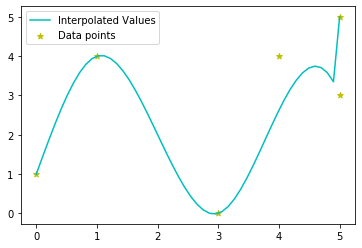

In [44]:
#Plotting
x_s = np.linspace(min(x), max(x), 50)    
S_interpolated =  [evaluate_spline(x, y, M, l) for l in x_s] 

plt.scatter(x, y, marker= '*', color = 'y', label='Data points')
plt.plot(x_s, S_interpolated, color='c', label= 'Interpolated Values')

plt.legend()
plt.show()